# Day 02 — Hiệu năng mô hình và so sánh ROI

[Slide của buổi học](_static/slides/day02_slides.pptx)

## Mục tiêu

- Tạo feature set cho intra, ring1, ring3, ring5
- Dùng cùng một pipeline để so sánh công bằng
- Đọc đúng ROC, AUC, confusion matrix
- Chọn một ROI chính để mang sang Day 03

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import mannwhitneyu

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def raw_url(relative_path):
    return f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/{relative_path}"

def load_csv(relative_repo_path):
    local_candidates = [
        Path(relative_repo_path),
        Path("..") / relative_repo_path,
        Path("/content") / REPO_NAME / relative_repo_path,
    ]
    for p in local_candidates:
        if p.exists():
            return pd.read_csv(p)
    return pd.read_csv(raw_url(relative_repo_path))

def build_lr_pipeline(feature_list, cat_cols):
    num_cols = [c for c in feature_list if c not in cat_cols]
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), [c for c in feature_list if c in cat_cols]),
    ])
    pipe = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    return pipe

In [2]:
df = load_csv('data/nsclc_egfr_radiomics_simplified.csv')

target = 'egfr_mutation'
clinical = ['age','sex','smoking_status','histology','stage','tumor_size_mm','tumor_volume_cm3','tp53_mutation']
cat_cols = ['sex','smoking_status','histology','stage']

roi_groups = {
    'intra': [c for c in df.columns if c.startswith('intra_')],
    'ring1': [c for c in df.columns if c.startswith('ring1_')],
    'ring3': [c for c in df.columns if c.startswith('ring3_')],
    'ring5': [c for c in df.columns if c.startswith('ring5_')],
}

idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.25,
    stratify=df[target],
    random_state=42
)
y_train = df.loc[idx_train, target]
y_test = df.loc[idx_test, target]

## Bước 1 — Đặt cùng một pipeline cho mọi ROI

Mỗi ROI phải đi qua đúng một cách tiền xử lý và một mô hình. Nếu thay đổi quá nhiều thứ cùng lúc thì không đọc được kết quả.

In [3]:
def evaluate_roi(df, roi_name):
    feature_list = clinical + roi_groups[roi_name]
    pipe = build_lr_pipeline(feature_list, cat_cols)
    pipe.fit(df.loc[idx_train, feature_list], y_train)

    pred_prob = pipe.predict_proba(df.loc[idx_test, feature_list])[:, 1]
    auc = roc_auc_score(y_test, pred_prob)
    brier = brier_score_loss(y_test, pred_prob)

    fpr, tpr, thr = roc_curve(y_test, pred_prob)
    youden = tpr - fpr
    j_idx = np.argmax(youden)
    best_thr = thr[j_idx]
    pred_label = (pred_prob >= best_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_label).ravel()

    return {
        'roi': roi_name,
        'auc': auc,
        'brier': brier,
        'threshold': best_thr,
        'sensitivity': tp / (tp + fn),
        'specificity': tn / (tn + fp),
        'accuracy': (tp + tn) / (tp + tn + fp + fn),
        'pred_prob': pred_prob,
        'fpr': fpr,
        'tpr': tpr
    }

results = [evaluate_roi(df, roi) for roi in roi_groups]
result_table = pd.DataFrame([{k: v for k, v in r.items() if k not in ['pred_prob','fpr','tpr']} for r in results]).round(3)
display(result_table.sort_values('auc', ascending=False))

,roi,auc,brier,threshold,sensitivity,specificity,accuracy
1,ring1,0.815,0.192,0.283,0.870,0.741,0.80
2,ring3,0.747,0.216,0.207,0.870,0.593,0.72
3,ring5,0.747,0.214,0.429,0.609,0.815,0.72
0,intra,0.694,0.226,0.160,0.957,0.333,0.62


## Bước 2 — Vẽ ROC để so sánh trực quan

Một bảng số là chưa đủ. Đường ROC giúp học sinh nhìn được ROI nào đứng cao hơn.

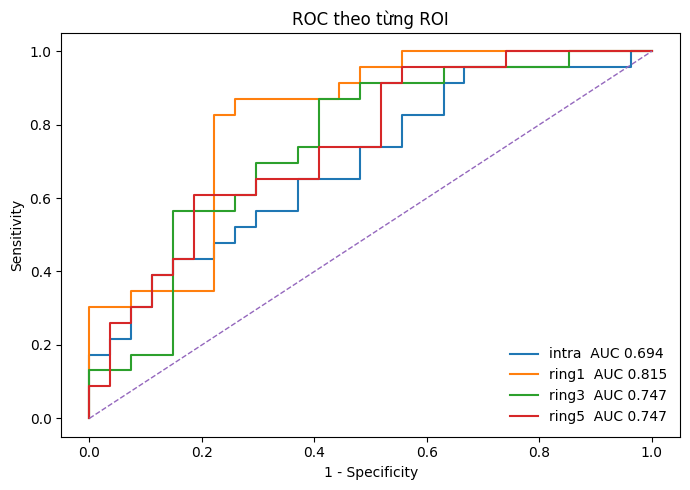

In [4]:
plt.figure(figsize=(7, 5))
for r in results:
    plt.plot(r['fpr'], r['tpr'], label=f"{r['roi']}  AUC {r['auc']:.3f}")
plt.plot([0, 1], [0, 1], '--', linewidth=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC theo từng ROI')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Bước 3 — Xem confusion matrix của ROI tốt nhất

Day 02 dùng ring1 làm mô hình chính để sang Day 03.

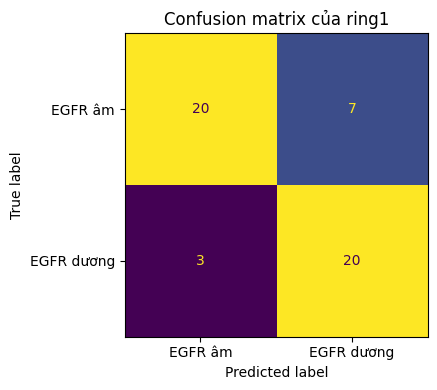

,Chỉ số,Giá trị
0,AUC,0.815
1,Brier,0.192
2,Threshold,0.283
3,Sensitivity,0.870
4,Specificity,0.741
5,Accuracy,0.800


In [5]:
best = max(results, key=lambda x: x['auc'])
best_pred = (best['pred_prob'] >= best['threshold']).astype(int)
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['EGFR âm', 'EGFR dương'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix của {best['roi']}")
plt.tight_layout()
plt.show()

best_summary = pd.DataFrame({
    'Chỉ số': ['AUC', 'Brier', 'Threshold', 'Sensitivity', 'Specificity', 'Accuracy'],
    'Giá trị': [
        round(best['auc'], 3),
        round(best['brier'], 3),
        round(best['threshold'], 3),
        round(best['sensitivity'], 3),
        round(best['specificity'], 3),
        round(best['accuracy'], 3),
    ]
})
display(best_summary)

## Kết quả demo của Day 02

Khi dùng cùng một pipeline, kết quả demo cho thấy:

- intra đạt AUC 0.694
- ring1 đạt AUC 0.815
- ring3 đạt AUC 0.747
- ring5 đạt AUC 0.747

Trong bộ demo này, ring1 là ROI tốt nhất nên được giữ lại cho Day 03.

## Sản phẩm sau bài học

- Một bảng so sánh AUC theo ROI
- Một hình ROC
- Một confusion matrix của ROI tốt nhất
- Một đoạn nhận xét ngắn trả lời câu hỏi vì sao chọn ROI đó

## Tự kiểm tra

1. Vì sao phải giữ nguyên pipeline khi so sánh ROI
2. Vì sao Day 02 chưa đủ để kết luận mô hình ổn định
3. AUC khác gì confusion matrix